# ECG Abnormality Classification with a Neural Network

## Business use case

Automated ECG screening can help prioritize waveforms for review when clinicians or monitoring teams face large volumes of signals. This project focuses on a simplified binary task: classifying ECG5000 samples as normal or abnormal.

## Objective

The goal is to build a compact feed-forward neural network on 140-point ECG traces, using a leakage-safe train/test split and feature normalization, then compare model performance with a majority-class baseline.

## Result in context

The saved test result is **99.2% accuracy** with test loss of about **0.0336**, compared with a majority-class baseline of **58.4%**.


## Step 1 — Load the ECG data

The dataset is represented as 140 sequential signal values plus a `Target` label. The first step defines the schema, loads the 4,998 observations, and verifies the shape and sample records.


In [ ]:

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide INFO logs (including the CPU feature guard message)

import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Reproducibility and display prefs
tf.random.set_seed(42)
pd.options.mode.chained_assignment = None


In [ ]:
# Build column names for 140 points + Target
names = list(range(140))
names.append('Target')
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv",names=names)
print(df.shape)
df.head()


(4998, 141)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,Target
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


## Step 2 — Separate the signal features from the target

The notebook checks the class distribution, builds the list of 140 numeric feature columns, and separates `Target` from the waveform values.


In [ ]:
numerics = names.copy()
numerics.remove('Target')
target_metrics = df['Target'].value_counts(normalize=True)
print(target_metrics)


Target
1.0    0.584034
0.0    0.415966
Name: proportion, dtype: float64


In [ ]:
#set the dependent variables to 'y'
y = df.pop('Target')
print(y.shape)
df.head()

(4998,)


,0,1,2,3,4,5,6,7,8,9,...,130,131,132,133,134,135,136,137,138,139
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456


## Step 3 — Create a stratified holdout and normalize safely

An 80/20 stratified split preserves the class mix. Feature means and standard deviations are computed from the training set and then applied to both train and test data, preventing leakage from the holdout set.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(3998, 140)
(1000, 140)
(3998,)
(1000,)


In [ ]:
# Assign the means to "means" and standard deviation to "sd"
means = X_train[numerics].mean()
sd = X_train[numerics].std()
print(means)

0     -0.273661
1     -1.663388
2     -2.501371
3     -3.125911
4     -3.170962
         ...   
135   -0.761967
136   -0.836599
137   -0.642616
138   -0.486079
139   -0.703261
Length: 140, dtype: float64


In [ ]:
X_train_norm = (X_train[numerics] - means)/sd
X_test_norm = (X_test[numerics] - means)/sd
X_train_norm.head()

,0,1,2,3,4,5,6,7,8,9,...,130,131,132,133,134,135,136,137,138,139
1209,1.408331,1.027357,0.422282,-0.365471,-1.294882,-1.711976,-1.434938,-0.171249,-0.269942,-0.049657,...,0.855561,0.581860,0.557059,0.424465,0.354896,0.404788,0.541570,0.805208,0.361952,-0.872679
2746,0.557429,0.097507,-0.685420,-1.101681,-1.066855,-0.421013,-0.035586,-0.092562,-0.091489,0.457134,...,0.911633,1.000096,1.243043,1.313269,1.201689,0.957828,0.835610,0.891449,0.660548,-0.251041
1756,-1.031546,-1.633050,-1.232334,-0.668085,-0.028766,0.657750,0.598224,0.622628,1.157431,0.772693,...,0.935729,1.286387,1.169558,1.128324,1.065973,0.704550,0.435909,0.362457,0.642063,-0.065379
347,0.417561,0.815545,0.826730,0.877935,0.862440,0.632517,0.057658,-0.419363,-0.719813,-0.727531,...,0.327241,-0.113610,-0.299015,-0.254349,-0.239847,-0.356422,-0.712441,-1.110022,-1.415160,-1.741672
360,0.011012,0.241263,0.315004,0.120670,-0.110642,-0.595113,-1.168250,-1.879666,-1.783870,-1.336235,...,-0.669544,-0.890123,-0.933998,-0.966901,-1.116715,-1.078590,-0.921125,-0.530104,-0.213146,0.740350


In [ ]:
X_train = X_train_norm.to_numpy()
X_test = X_test_norm.to_numpy()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(3998, 140) (3998,) (1000, 140) (1000,)


## Step 4 — Build the neural network

The normalized 140-dimensional signal is passed to a compact dense network with a sigmoid output for binary classification. This provides a lightweight benchmark without introducing a more specialized temporal architecture.


In [ ]:
num_columns = X_train.shape[1]
input = keras.Input(shape=(num_columns,))
h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)
output = keras.layers.Dense(1,activation="sigmoid",name="Output")(h)
model = keras.Model(input,output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │         2,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273 (8.88 KB)

 Trainable params: 2,273 (8.88 KB)

 Non-trainable params: 0 (0.00 B)

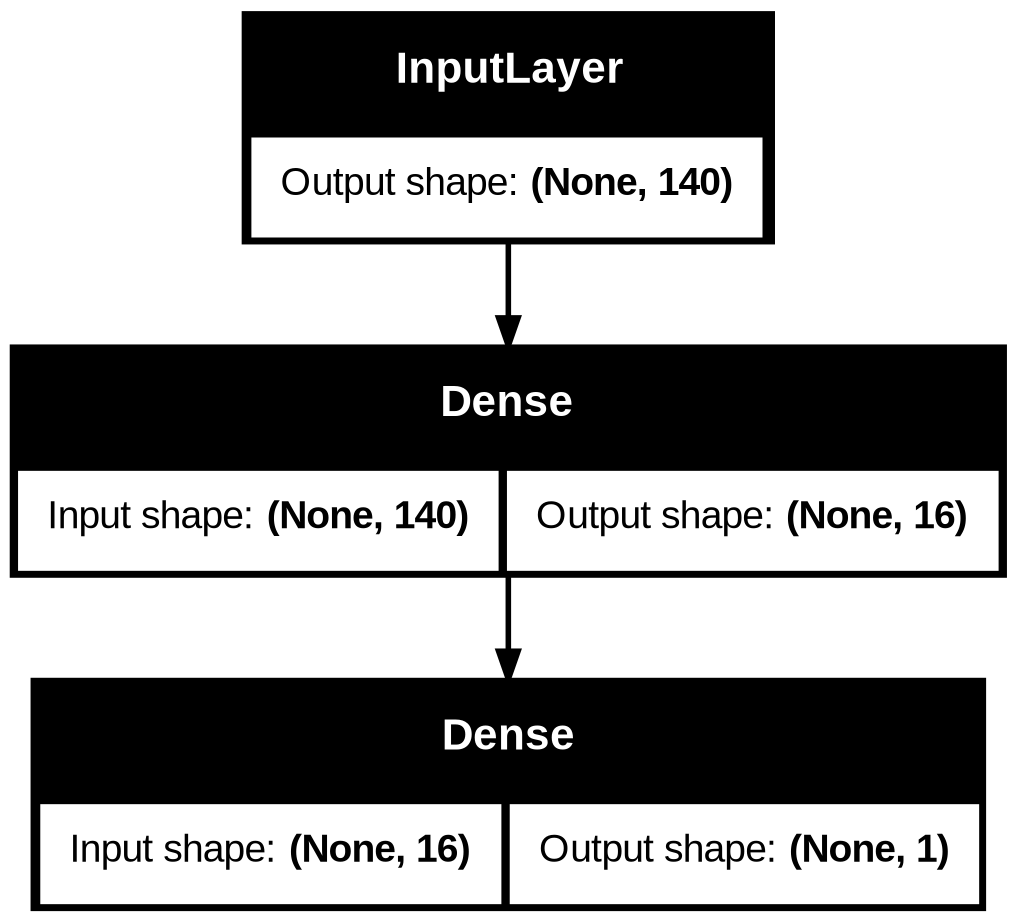

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

## Step 5 — Train and inspect the learning curves

The model uses Adagrad with binary cross-entropy. Training history is plotted to compare train and validation behavior across epochs.


In [ ]:
model.compile(optimizer="Adagrad",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
history = model.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=36,
                    validation_split=0.2)

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8249 - loss: 0.4505 - val_accuracy: 0.9025 - val_loss: 0.3609
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9243 - loss: 0.2970 - val_accuracy: 0.9325 - val_loss: 0.2721
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9450 - loss: 0.2313 - val_accuracy: 0.9500 - val_loss: 0.2224
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9597 - loss: 0.1932 - val_accuracy: 0.9538 - val_loss: 0.1899
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9653 - loss: 0.1678 - val_accuracy: 0.9600 - val_loss: 0.1667
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9684 - loss: 0.1495 - val_accuracy: 0.9663 - val_loss: 0.1492
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9725 - loss: 0.1356 - val_accuracy: 0.9700 - val_loss: 0.1356
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9744 - loss: 0.1248 - val_accuracy: 0.9712 - v

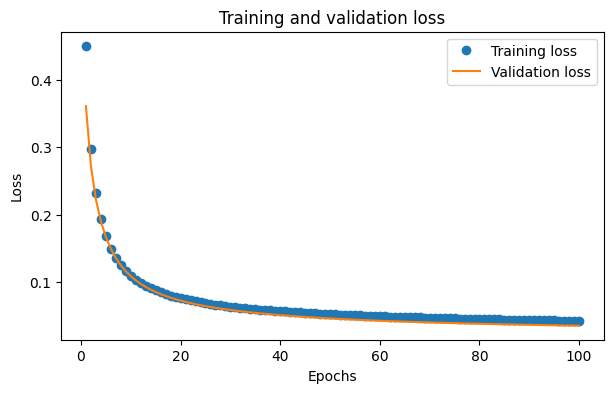

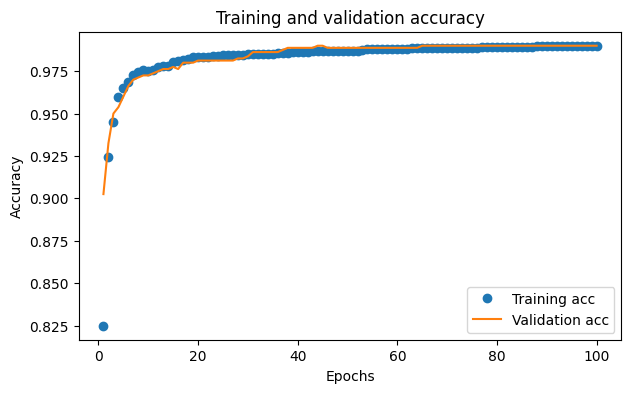

In [ ]:
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# Loss
plt.figure(figsize=(7,4))
plt.plot(epochs, history_dict['loss'], 'o', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], '-', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.show()

# Accuracy
plt.figure(figsize=(7,4))
plt.plot(epochs, history_dict['accuracy'], 'o', label='Training acc')
plt.plot(epochs, history_dict['val_accuracy'], '-', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();
plt.show()


## Step 6 — Evaluate against the class baseline

The final evaluation uses the untouched test split. The notebook also computes the majority-class accuracy so the model's performance is interpreted relative to a simple baseline rather than in isolation.


In [ ]:
score,acc = model.evaluate(X_test,y_test)
print({'test_loss': score, 'test_accuracy': acc})

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9920 - loss: 0.0336
{'test_loss': 0.03360049054026604, 'test_accuracy': 0.9919999837875366}


In [ ]:
# Baseline: always predict the majority class
class_dist = y.value_counts(normalize=True)
majority_class = class_dist.idxmax()
baseline_acc = class_dist.max()

print("Class distribution:\n", class_dist)
print("\nMajority class:", majority_class)
print("Baseline accuracy (always predicting majority class):", f"{baseline_acc:.3f}")


Class distribution:
 Target
1.0    0.584034
0.0    0.415966
Name: proportion, dtype: float64

Majority class: 1.0
Baseline accuracy (always predicting majority class): 0.584


In [ ]:
print("Model test accuracy:", f"{acc:.3f}")

Model test accuracy: 0.992


## Technical conclusions

The model reaches **99.2% test accuracy**, far above the **58.4%** majority baseline. For this benchmark, a dense network is sufficient to capture strong discriminatory structure in the 140-point traces.

The score is strong, but accuracy can hide clinically important error asymmetry. A production-oriented version should report sensitivity and specificity for the abnormal class, ROC/PR curves, calibration, and performance by rhythm subtype. I would also compare this dense baseline with 1D CNN or sequence-based architectures that make more explicit use of local temporal structure.

## Business conclusions

As a screening layer, a high-performing classifier could reduce manual review load by prioritizing suspicious traces. The operational decision threshold should be chosen around the cost of missing abnormal cases, not around accuracy alone.

## Limitations and next steps

This notebook uses a benchmark split and a binary target. External-device data, patient-level splitting, signal-quality checks, and clinical validation would be required before any real-world use.
